###Import Libraries

In [5]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

###Data Generation Function

In [6]:
def generate_wholesale_data(num_days=730, num_items=10):
    np.random.seed(42)
    start_date = datetime(2024, 1, 1)
    date_list = [start_date + timedelta(days=i) for i in range(num_days)]
    
    items = [
        {"id": "SKU_001", "name": "Cooking Oil 5L", "base_price": 2500, "category": "Edible Oil"},
        {"id": "SKU_002", "name": "Flour (Aata) 10kg", "base_price": 1200, "category": "Grains"},
        {"id": "SKU_003", "name": "Tea Dust 1kg", "base_price": 1400, "category": "Beverages"},
        {"id": "SKU_004", "name": "Sugar 50kg Bag", "base_price": 7000, "category": "Grains"},
        {"id": "SKU_005", "name": "Cold Drink 1.5L Box", "base_price": 1800, "category": "Beverages"},
        {"id": "SKU_006", "name": "Washing Powder 5kg", "base_price": 1600, "category": "Household"},
        {"id": "SKU_007", "name": "Basmati Rice 20kg", "base_price": 5500, "category": "Grains"},
        {"id": "SKU_008", "name": "Bath Soap Pack (12x)", "base_price": 1500, "category": "Personal Care"},
        {"id": "SKU_009", "name": "UHT Milk Carton (12x)", "base_price": 3200, "category": "Dairy"},
        {"id": "SKU_010", "name": "Spices Mix Bundle", "base_price": 900, "category": "Grocery"}
    ]
    
    records = []
    
    for date in date_list:
        is_weekend = date.weekday() >= 5
        month = date.month
        
        for item in items[:num_items]:
            base_demand = np.random.poisson(lam=40)
            
            # Seasonality logic
            season_multiplier = 1.0
            if item["category"] == "Beverages" and month in [5, 6, 7, 8]:
                season_multiplier = 1.6
            elif item["category"] in ["Grains", "Edible Oil"] and month in [3, 4, 9]:
                season_multiplier = 1.3
                
            weekend_multiplier = 0.8 if is_weekend else 1.15
            
            quantity_sold = int(base_demand * season_multiplier * weekend_multiplier)
            quantity_sold = max(0, quantity_sold)
            
            unit_price = item["base_price"]
            revenue = quantity_sold * unit_price
            
            records.append({
                "Date": date.strftime("%Y-%m-%d"),
                "SKU_ID": item["id"],
                "Item_Name": item["name"],
                "Category": item["category"],
                "Unit_Price": unit_price,
                "Quantity_Sold": quantity_sold,
                "Total_Revenue": revenue
            })
            
    df = pd.DataFrame(records)
    return df

print("Data generation function ready!")

Data generation function ready!


Generate Raw Data

Feature Engineering Function

###Generate Raw Data

In [7]:
print("Generating 2-year wholesale sales data...")
raw_df = generate_wholesale_data()
print(f"Total Records Generated: {len(raw_df)}")
raw_df.head()

Generating 2-year wholesale sales data...
Total Records Generated: 7300


,Date,SKU_ID,Item_Name,Category,Unit_Price,Quantity_Sold,Total_Revenue
0,2024-01-01,SKU_001,Cooking Oil 5L,Edible Oil,2500,43,107500
1,2024-01-01,SKU_002,Flour (Aata) 10kg,Grains,1200,50,60000
2,2024-01-01,SKU_003,Tea Dust 1kg,Beverages,1400,37,51800
3,2024-01-01,SKU_004,Sugar 50kg Bag,Grains,7000,48,336000
4,2024-01-01,SKU_005,Cold Drink 1.5L Box,Beverages,1800,54,97200


###Feature Engineering Function

In [8]:
def create_time_series_features(df):
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(by=["SKU_ID", "Date"]).reset_index(drop=True)
    
    # Calendar Features
    df["Day_Of_Week"] = df["Date"].dt.dayofweek
    df["Day_Of_Month"] = df["Date"].dt.day
    df["Month"] = df["Date"].dt.month
    df["Is_Weekend"] = df["Day_Of_Week"].apply(lambda x: 1 if x >= 5 else 0)
    
    # Lag Features (Past sales)
    for lag in [1, 7, 14, 30]:
        df[f"Quantity_Lag_{lag}"] = df.groupby("SKU_ID")["Quantity_Sold"].shift(lag)
        
    # Rolling Statistics (Moving Averages & Std)
    for window in [7, 14, 30]:
        df[f"Rolling_Mean_{window}"] = df.groupby("SKU_ID")["Quantity_Sold"].transform(lambda x: x.shift(1).rolling(window).mean())
        df[f"Rolling_Std_{window}"] = df.groupby("SKU_ID")["Quantity_Sold"].transform(lambda x: x.shift(1).rolling(window).std())
        
    # Drop NaN rows generated due to shifts
    df_cleaned = df.dropna().reset_index(drop=True)
    return df_cleaned

print("Feature engineering function ready!")

Feature engineering function ready!


###Process Data and Save to CSV

In [9]:
print("Processing time-series features...")
processed_df = create_time_series_features(raw_df)

# Save file locally
processed_df.to_csv("wholesale_sales_processed.csv", index=False)
print("Data processing complete! Saved as 'wholesale_sales_processed.csv'")

# View Processed Output Sample
processed_df[["Date", "SKU_ID", "Quantity_Sold", "Quantity_Lag_1", "Quantity_Lag_7", "Rolling_Mean_7"]].head(10)

Processing time-series features...
Data processing complete! Saved as 'wholesale_sales_processed.csv'


,Date,SKU_ID,Quantity_Sold,Quantity_Lag_1,Quantity_Lag_7,Rolling_Mean_7
0,2024-01-31,SKU_001,44,35.0,46.0,37.285714
1,2024-02-01,SKU_001,36,44.0,49.0,37.000000
2,2024-02-02,SKU_001,47,36.0,37.0,35.142857
3,2024-02-03,SKU_001,33,47.0,33.0,36.571429
4,2024-02-04,SKU_001,40,33.0,26.0,36.571429
5,2024-02-05,SKU_001,36,40.0,35.0,38.571429
6,2024-02-06,SKU_001,49,36.0,35.0,38.714286
7,2024-02-07,SKU_001,51,49.0,44.0,40.714286
8,2024-02-08,SKU_001,49,51.0,36.0,41.714286
9,2024-02-09,SKU_001,50,49.0,47.0,43.571429


###Load Processed Data & Time-Based Train-Test Split

In [10]:
import pandas as pd
import numpy as np

# Load the processed dataset saved in Day 1
df = pd.read_csv("wholesale_sales_processed.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Select Features and Target Variable
features = [
    'Unit_Price', 'Day_Of_Week', 'Day_Of_Month', 'Month', 'Is_Weekend',
    'Quantity_Lag_1', 'Quantity_Lag_7', 'Quantity_Lag_14', 'Quantity_Lag_30',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Rolling_Std_14', 
    'Rolling_Mean_30', 'Rolling_Std_30'
]
target = 'Quantity_Sold'

# Split by Date (80% Train, 20% Test)
split_date = df['Date'].max() - pd.Timedelta(days=90) # Last 90 days as test set

train_df = df[df['Date'] <= split_date]
test_df = df[df['Date'] > split_date]

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Training Set Records: {len(X_train)}")
print(f"Testing Set Records: {len(X_test)}")

Training Set Records: 6100
Testing Set Records: 900


###Cell 8: Train XGBoost Forecasting Model

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Initialize & Train XGBoost Model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("--- Model Performance Metrics (XGBoost) ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print("-------------------------------------------")

--- Model Performance Metrics (XGBoost) ---
Root Mean Squared Error (RMSE): 6.36 units
Mean Absolute Error (MAE): 5.04 units
-------------------------------------------


###Plot Predictions vs Actual Sales for a Sample SKU

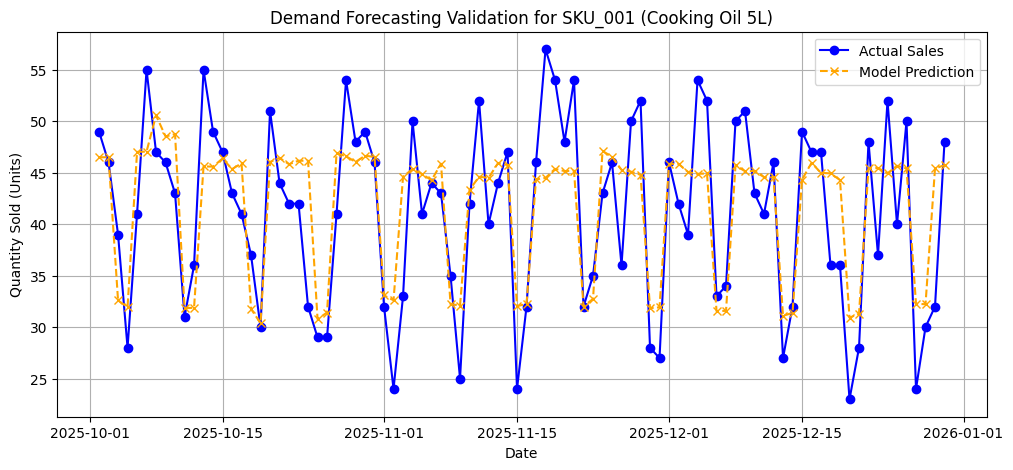

In [14]:
import matplotlib.pyplot as plt

# Test set par predictions attach karein
test_results = test_df.copy()
test_results['Predicted_Quantity'] = y_pred

# Specific item (SKU_001 - Cooking Oil) ki performance plot karein
sample_sku = "SKU_001"
sku_data = test_results[test_results['SKU_ID'] == sample_sku].sort_values('Date')

plt.figure(figsize=(12, 5))
plt.plot(sku_data['Date'], sku_data['Quantity_Sold'], label='Actual Sales', color='blue', marker='o')
plt.plot(sku_data['Date'], sku_data['Predicted_Quantity'], label='Model Prediction', color='orange', linestyle='--', marker='x')

plt.title(f"Demand Forecasting Validation for {sample_sku} ({sku_data['Item_Name'].iloc[0]})")
plt.xlabel("Date")
plt.ylabel("Quantity Sold (Units)")
plt.legend()
plt.grid(True)
plt.show()

###Save Trained XGBoost Model

In [15]:
import joblib

joblib.dump(model, "inventory_forecasting_model.pkl")
print("Model saved successfully as 'inventory_forecasting_model.pkl'!")

Model saved successfully as 'inventory_forecasting_model.pkl'!


###Inventory Optimization Engine (Re-Order Levels & Dead Stock Alerts)

In [16]:
def run_inventory_engine(current_df, model, lead_time_days=3, service_level_factor=1.65):
    """
    Calculates Re-Order Point (ROP), Safety Stock, and generates 'What to Buy' Alerts.
    service_level_factor = 1.65 corresponds to a 95% service level (low stockout risk).
    """
    latest_date = current_df['Date'].max()
    latest_data = current_df[current_df['Date'] == latest_date].copy()
    
    # Predict next day demand using our trained XGBoost model
    latest_features = latest_data[features]
    latest_data['Predicted_Next_Day_Demand'] = model.predict(latest_features)
    
    inventory_summary = []
    
    for sku in latest_data['SKU_ID'].unique():
        item_data = current_df[current_df['SKU_ID'] == sku].sort_values('Date')
        item_info = latest_data[latest_data['SKU_ID'] == sku].iloc[0]
        
        # 1. Calculate Historical Demand Variance for Safety Stock
        std_daily_sales = item_data['Quantity_Sold'].tail(30).std()
        avg_daily_sales = item_data['Quantity_Sold'].tail(30).mean()
        
        # Formula: Safety Stock = Z * std_dev * sqrt(Lead_Time)
        safety_stock = int(service_level_factor * std_daily_sales * np.sqrt(lead_time_days))
        
        # Formula: Re-Order Point (ROP) = (Avg Daily Sales * Lead Time) + Safety Stock
        reorder_point = int((avg_daily_sales * lead_time_days) + safety_stock)
        
        # Simulate current stock in warehouse (random simulated level for testing)
        simulated_current_stock = np.random.randint(low=int(reorder_point * 0.4), high=int(reorder_point * 2.2))
        
        # 2. Re-Order Decision Logic
        needs_reorder = simulated_current_stock <= reorder_point
        suggested_order_qty = max(0, (reorder_point * 2) - simulated_current_stock) if needs_reorder else 0
        
        # 3. Dead Stock Indicator (If average sales in last 30 days is extremely low)
        is_dead_stock = avg_daily_sales < 5 and simulated_current_stock > 50
        
        inventory_summary.append({
            "SKU_ID": sku,
            "Item_Name": item_info['Item_Name'],
            "Category": item_info['Category'],
            "Current_Stock": simulated_current_stock,
            "ReOrder_Point": reorder_point,
            "Safety_Stock": safety_stock,
            "Predicted_Daily_Demand": int(item_info['Predicted_Next_Day_Demand']),
            "Action_Required": "ORDER NOW" if needs_reorder else "STOCK OK",
            "Suggested_Order_Qty": suggested_order_qty,
            "Dead_Stock_Warning": "YES - CAPITAL BLOCKED" if is_dead_stock else "NO"
        })
        
    summary_df = pd.DataFrame(inventory_summary)
    return summary_df

# Execute Decision Engine
inventory_status = run_inventory_engine(df, model)
print("=== INVENTORY DECISION ENGINE OUTPUT ===")
inventory_status

=== INVENTORY DECISION ENGINE OUTPUT ===


,SKU_ID,Item_Name,Category,Current_Stock,ReOrder_Point,Safety_Stock,Predicted_Daily_Demand,Action_Required,Suggested_Order_Qty,Dead_Stock_Warning
0,SKU_001,Cooking Oil 5L,Edible Oil,242,147,26,45,STOCK OK,0,NO
1,SKU_002,Flour (Aata) 10kg,Grains,240,144,23,46,STOCK OK,0,NO
2,SKU_003,Tea Dust 1kg,Beverages,203,153,26,45,STOCK OK,0,NO
3,SKU_004,Sugar 50kg Bag,Grains,103,152,25,46,ORDER NOW,201,NO
4,SKU_005,Cold Drink 1.5L Box,Beverages,74,159,31,45,ORDER NOW,244,NO
5,SKU_006,Washing Powder 5kg,Household,69,155,25,45,ORDER NOW,241,NO
6,SKU_007,Basmati Rice 20kg,Grains,137,146,26,45,ORDER NOW,155,NO
7,SKU_008,Bath Soap Pack (12x),Personal Care,220,149,23,45,STOCK OK,0,NO
8,SKU_009,UHT Milk Carton (12x),Dairy,275,150,24,45,STOCK OK,0,NO
9,SKU_010,Spices Mix Bundle,Grocery,309,155,25,46,STOCK OK,0,NO


In [1]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.express as px

# Page Configuration
st.set_page_config(
    page_title="SmartStock AI - Wholesale Demand Forecasting Engine",
    page_icon="📦",
    layout="wide"
)

# Load Trained XGBoost Model
@st.cache_resource
def load_model():
    return joblib.load("inventory_forecasting_model.pkl")

try:
    model = load_model()
except Exception as e:
    st.error("Model file 'inventory_forecasting_model.pkl' not found. Please train and save the model first.")
    st.stop()

# Header & Title
st.title("📦 SmartStock AI: Wholesale Demand & Inventory Engine")
st.markdown("### Decision Support System for Wholesale Distributors & Galla Mandi Merchants")
st.markdown("---")

# Sidebar - Data Input Selection
st.sidebar.header("1. Data Source Options")
data_source = st.sidebar.radio("Select Input Mode:", ["Use Default System Data", "Upload Client CSV File"])

if data_source == "Use Default System Data":
    try:
        df = pd.read_csv("wholesale_sales_processed.csv")
        df['Date'] = pd.to_datetime(df['Date'])
        st.sidebar.success("Loaded 'wholesale_sales_processed.csv' successfully!")
    except:
        st.sidebar.error("Default CSV file not found.")
        st.stop()
else:
    uploaded_file = st.sidebar.file_uploader("Upload Wholesale Sales CSV", type=["csv"])
    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)
        df['Date'] = pd.to_datetime(df['Date'])
        st.sidebar.success("Custom CSV Uploaded Successfully!")
    else:
        st.info("Please upload a CSV file with required columns (Date, SKU_ID, Item_Name, Quantity_Sold, Unit_Price, etc.)")
        st.stop()

# Sidebar - Controls & Parameters
st.sidebar.header("2. Inventory Control Parameters")
lead_time = st.sidebar.slider("Supplier Lead Time (Days)", min_value=1, max_value=14, value=3)
service_level = st.sidebar.selectbox("Stockout Risk Service Level", ["95% (Recommended)", "90% (Moderate Risk)", "99% (High Protection)"])

service_level_dict = {"90% (Moderate Risk)": 1.28, "95% (Recommended)": 1.65, "99% (High Protection)": 2.33}
z_score = service_level_dict[service_level]

# Feature columns list used during model training
features = [
    'Unit_Price', 'Day_Of_Week', 'Day_Of_Month', 'Month', 'Is_Weekend',
    'Quantity_Lag_1', 'Quantity_Lag_7', 'Quantity_Lag_14', 'Quantity_Lag_30',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Rolling_Std_14', 
    'Rolling_Mean_30', 'Rolling_Std_30'
]

# Calculate Predictions & Decision Logic
latest_date = df['Date'].max()
latest_data = df[df['Date'] == latest_date].copy()

# Model Predictions
latest_features = latest_data[features]
latest_data['Predicted_Demand'] = model.predict(latest_features)

inventory_list = []
for sku in latest_data['SKU_ID'].unique():
    item_data = df[df['SKU_ID'] == sku].sort_values('Date')
    item_info = latest_data[latest_data['SKU_ID'] == sku].iloc[0]
    
    std_sales = item_data['Quantity_Sold'].tail(30).std()
    avg_sales = item_data['Quantity_Sold'].tail(30).mean()
    
    safety_stock = int(z_score * std_sales * np.sqrt(lead_time))
    reorder_point = int((avg_sales * lead_time) + safety_stock)
    
    # Simulated current stock for demo
    np.random.seed(hash(sku) % 1000)
    current_stock = np.random.randint(low=int(reorder_point * 0.3), high=int(reorder_point * 2.0))
    
    needs_order = current_stock <= reorder_point
    order_qty = max(0, (reorder_point * 2) - current_stock) if needs_order else 0
    is_dead = avg_sales < 5 and current_stock > 50
    
    inventory_list.append({
        "SKU ID": sku,
        "Item Name": item_info['Item_Name'],
        "Category": item_info['Category'],
        "Current Stock": current_stock,
        "Re-Order Point": reorder_point,
        "Safety Stock": safety_stock,
        "Predicted Daily Demand": int(item_info['Predicted_Demand']),
        "Status": "🚨 ORDER NOW" if needs_order else "✅ OK",
        "Suggested Order Qty": order_qty,
        "Dead Stock Warning": "⚠️ CAPITAL BLOCKED" if is_dead else "Clear"
    })

inventory_df = pd.DataFrame(inventory_list)

# Dashboard High-Level Metrics
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Items (SKUs)", len(inventory_df))
col2.metric("Critical Re-Orders Required", len(inventory_df[inventory_df['Status'] == "🚨 ORDER NOW"]))
col3.metric("Dead Stock Items", len(inventory_df[inventory_df['Dead Stock Warning'] != "Clear"]))
col4.metric("Avg Predicted Daily Demand", f"{int(inventory_df['Predicted Daily Demand'].mean())} units")

st.markdown("---")

# Tabbed Layout
tab1, tab2, tab3 = st.tabs(["🛒 'What to Buy Today' Action List", "📈 Demand Forecast Graphs", "⚠️ Dead Stock & Risk Analysis"])

with tab1:
    st.subheader("Supplier Order Recommendations")
    st.markdown("Automated calculation based on **Predicted Demand**, **Lead Time**, and **Safety Stock** limits.")
    
    # Filter for Order Now
    order_now_df = inventory_df[inventory_df['Status'] == "🚨 ORDER NOW"]
    if not order_now_df.empty:
        st.dataframe(order_now_df, width="stretch")
    else:
        st.success("All stock levels are sufficient! No immediate orders required today.")
        
    st.markdown("#### Full Warehouse Inventory Status")
    st.dataframe(inventory_df, width="stretch")

with tab2:
    st.subheader("Historical vs Predicted Sales Demand Analytics")
    selected_sku = st.selectbox("Select Item to Analyze:", df['Item_Name'].unique())
    
    sku_data = df[df['Item_Name'] == selected_sku].sort_values('Date').tail(90)
    
    fig = px.line(sku_data, x='Date', y='Quantity_Sold', title=f"90-Day Demand Trend for {selected_sku}",
                  labels={'Quantity_Sold': 'Units Sold', 'Date': 'Date'}, markers=True)
    st.plotly_chart(fig, width="stretch")

with tab3:
    st.subheader("Dead Stock & Capital Risk Detector")
    dead_stock_df = inventory_df[inventory_df['Dead Stock Warning'] != "Clear"]
    
    if not dead_stock_df.empty:
        st.warning("The following items have very low turnover rate while holding excessive inventory space. Consider offering discounts or promotional bundles.")
        st.dataframe(dead_stock_df[["SKU ID", "Item Name", "Category", "Current Stock", "Dead Stock Warning"]], width="stretch")
    else:
        st.success("No critical dead stock detected in warehouse inventory.")

# Footer
st.markdown("---")
st.markdown("⚡ *Powered by SmartStock AI Pipeline - Built with Python, XGBoost & Streamlit*")

2026-09-30 19:38:24.371 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 19:38:24.374 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 19:38:26.963 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 19:38:28.771 
  command:

    streamlit run C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-30 19:38:28.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 19:38:28.778 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-30 19

DeltaGenerator()

In [25]:
!streamlit run file_ka_naam.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: file_ka_naam.py
